<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week5_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week5 — Histogram, Histogram Equalization, dan Dithering**

In [1]:
# ===== SEL IDENTITAS JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Risky Adi Prasetya'
NIM = '244107020153'

N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N:', N)
for k, v in PARAM.items():
    print(f'{k:<6} : {v}')
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Risky Adi Prasetya
NIM    : 244107020153 | N: 153
bins   : 16
clip   : 2.5
tile   : 3
L      : 2
WAKTU  : 2026-10-03 20:42:24 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 0f68253922684a2d


# **E-1 PERCOBAAN HISTOGRAM**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Konfigurasi Path Folder
CONTOH = '/content/drive/MyDrive/PCVK2026/Images'
BASE = '/content/drive/MyDrive/PCVK2026/Images/244107020153'

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

## Langkah 3 - Flowchart

Tahap 1: Lena.jpg, tahap 2: KTM1B.jpeg

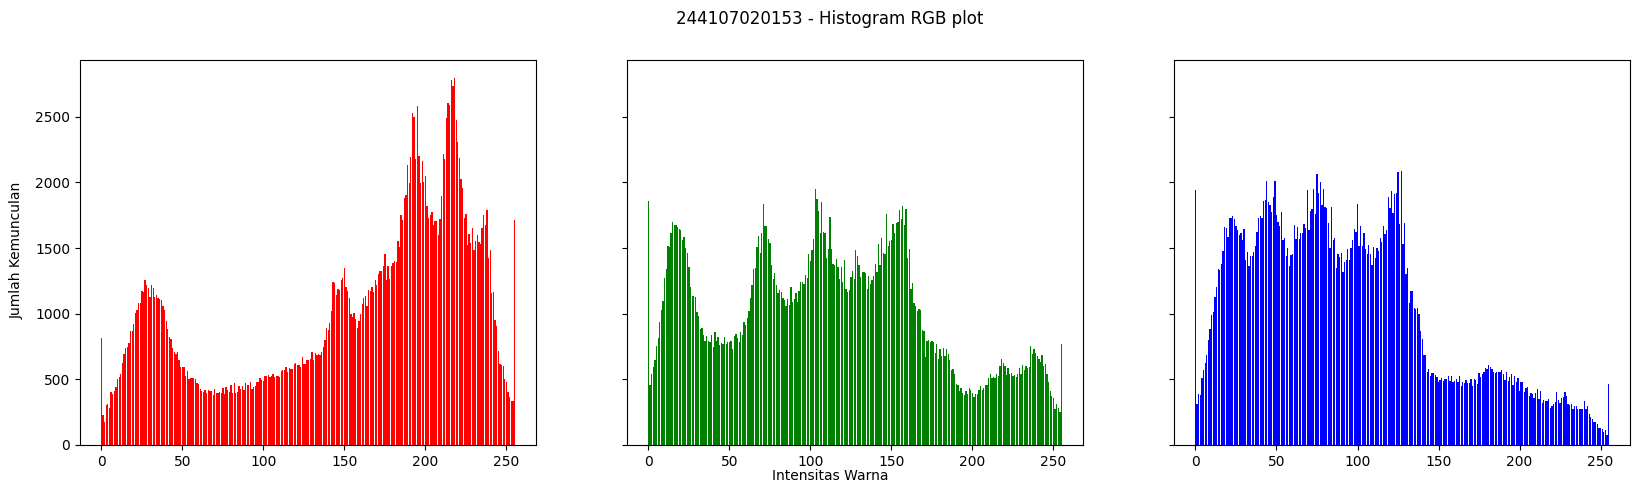

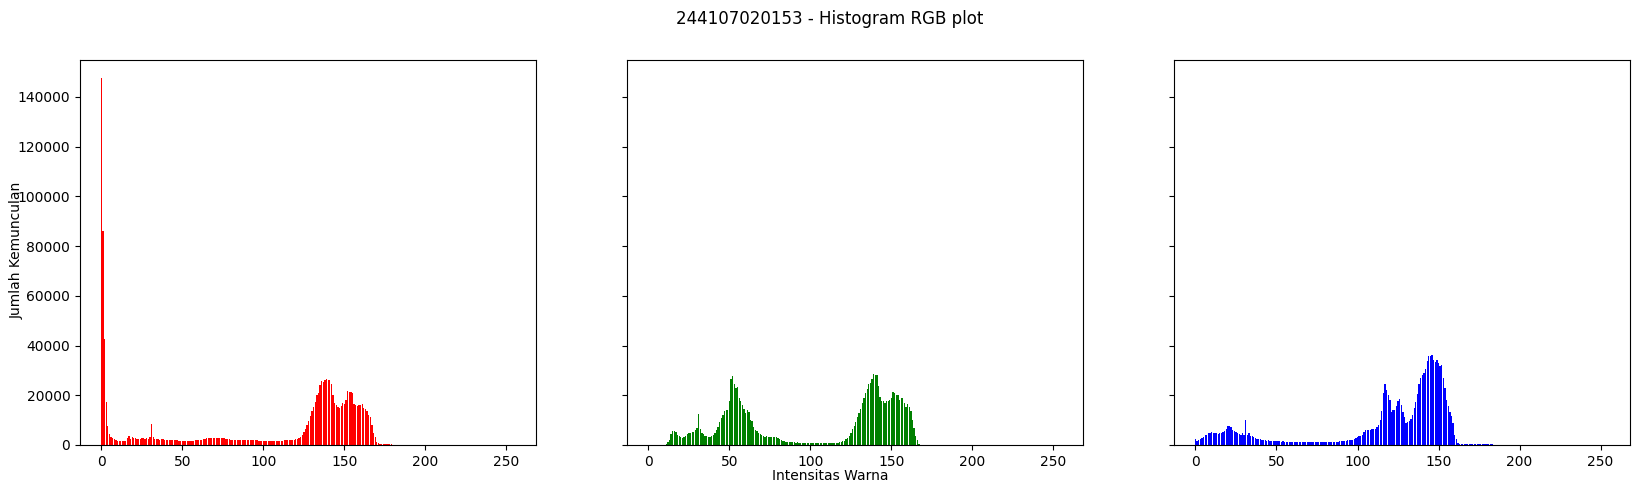

In [4]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)         # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):           # 2. telusuri setiap baris
        for x in range(img.shape[1]):       #    dan setiap kolom
            h[img[y, x]] += 1               # 3. tambah 1 sesuai nilai piksel
    return h


def tampilkan_histogram_rgb(berkas, judul_prefix):
    img = cv.imread(berkas)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, depth = np.shape(img)
    names = np.arange(256)
    red, green, blue = [0] * 256, [0] * 256, [0] * 256

    for y in range(height):
        for x in range(width):
            red[img[y][x][0]]   += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]]  += 1

    fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
    fig.suptitle(judul_prefix + ' - Histogram RGB plot')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

    axs[0].bar(names, red, color='red')
    axs[1].bar(names, green, color='green')
    axs[2].bar(names, blue, color='blue')
    plt.show()


# Tahap 1: citra contoh
tampilkan_histogram_rgb(CONTOH + '/lena.jpg', NIM)

# Tahap 2: citra KTM
tampilkan_histogram_rgb(BASE + '/KTM1b.jpeg', NIM)

## PERTANYAAN PRAKTIKUM E1

In [5]:
# Soal 1 - histogram_manual vs numpy.histogram vs cv.calcHist
def bandingkan_tiga_metode(berkas, judul):
    gray = cv.imread(berkas, cv.IMREAD_GRAYSCALE)
    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()

    sel_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    sel_manual_cv    = np.max(np.abs(h_manual - h_cv))

    print(judul)
    print('  selisih maksimum manual vs numpy.histogram :', sel_manual_numpy)
    print('  selisih maksimum manual vs cv.calcHist     :', sel_manual_cv)
    assert sel_manual_numpy == 0 and sel_manual_cv == 0, 'Selisih harus nol!'
    return h_manual, h_numpy, h_cv

_ = bandingkan_tiga_metode(CONTOH + '/lena.jpg', NIM + ' - lena.jpg')
_ = bandingkan_tiga_metode(BASE + '/KTM1b.jpeg', NIM + ' - KTM1b.jpeg')

244107020153 - lena.jpg
  selisih maksimum manual vs numpy.histogram : 0
  selisih maksimum manual vs cv.calcHist     : 0.0
244107020153 - KTM1b.jpeg
  selisih maksimum manual vs numpy.histogram : 0
  selisih maksimum manual vs cv.calcHist     : 0.0


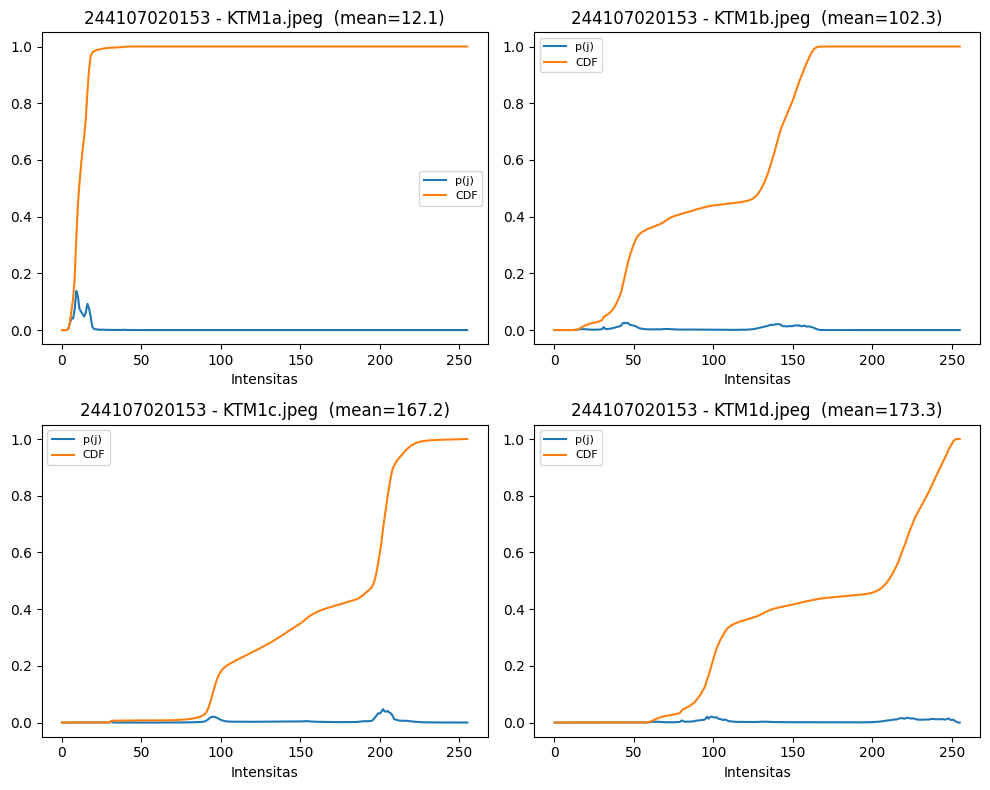

In [6]:
# Soal 2 - histogram ternormalisasi p(j) dan CDF untuk KTM1a–KTM1d (2x2)
ktms = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for ax, f in zip(axs.flat, ktms):
    gray = cv.imread(BASE + '/' + f, cv.IMREAD_GRAYSCALE)
    h = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
    p = h / gray.size
    cdf = np.cumsum(p)

    ax.plot(p, label='p(j)')
    ax.plot(cdf, label='CDF')
    ax.set_title(NIM + ' - ' + f + f'  (mean={gray.mean():.1f})')
    ax.set_xlabel('Intensitas')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

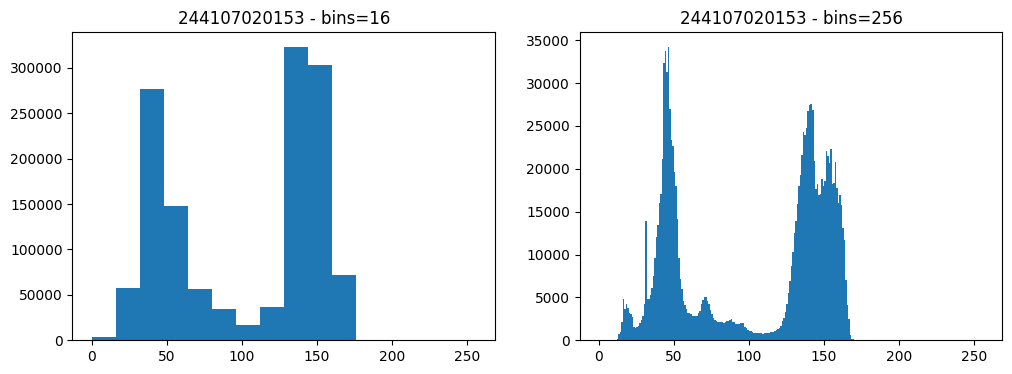

In [7]:
# Soal 3 - histogram KTM1b.jpg dengan bins=PARAM['bins'] vs 256 bin
gray_ktmb = cv.imread(BASE + '/KTM1b.jpeg', cv.IMREAD_GRAYSCALE)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(gray_ktmb.ravel(), bins=PARAM['bins'], range=(0, 256))
axs[0].set_title(NIM + f" - bins={PARAM['bins']}")

axs[1].hist(gray_ktmb.ravel(), bins=256, range=(0, 256))
axs[1].set_title(NIM + " - bins=256")

plt.show()

---
# **E-2 PERCOBAAN HISTOGRAM EQUALIZATION**


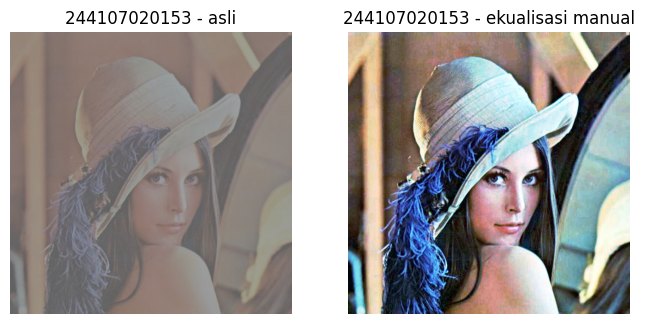

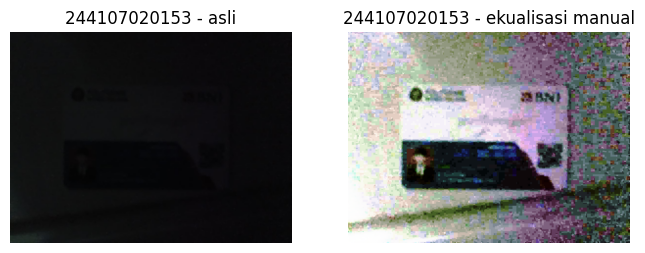

In [8]:
# Step 1 - Histogram equalization manual (flowchart, per kanal)
def hist_eq_manual(gray, L=256):
    h, w = gray.shape
    hist = histogram_manual(gray, L)          # frekuensi tiap intensitas
    Ci = np.cumsum(hist)                      # distribusi kumulatif
    lut = np.round(Ci * (L - 1) / (h * w)).astype(np.uint8)   # rumus Ko
    return lut[gray]                          # transformasi kembali ke citra


def equalize_manual_rgb(berkas):
    bgr = cv.imread(berkas)
    kanal = list(cv.split(bgr))
    kanal_eq = [hist_eq_manual(k) for k in kanal]
    return bgr, cv.merge(kanal_eq)


def tampilkan_sebelum_sesudah(asli, hasil, judul):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(cv.cvtColor(asli, cv.COLOR_BGR2RGB))
    axs[0].set_title(judul + ' - asli')
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title(judul + ' - ekualisasi manual')
    axs[1].axis('off')
    plt.show()


# Tahap 1: citra contoh (cocokkan dengan gambar contoh pada modul)
asli_lc, eq_lc_manual = equalize_manual_rgb(CONTOH + '/lena_lc.jpg')
tampilkan_sebelum_sesudah(asli_lc, eq_lc_manual, NIM)

# Tahap 2: citra KTM Anda
asli_ktma, eq_ktma_manual = equalize_manual_rgb(BASE + '/KTM1a.jpeg')
tampilkan_sebelum_sesudah(asli_ktma, eq_ktma_manual, NIM)

In [9]:
# Step 2 - bandingkan dengan cv2.equalizeHist
def equalize_cv_rgb(berkas):
    bgr = cv.imread(berkas)
    b, g, r = cv.split(bgr)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    return bgr, cv.merge([b_equalized, g_equalized, r_equalized])

# Tahap 1: lena_lc.jpg
_, eq_lc_cv = equalize_cv_rgb(CONTOH + '/lena_lc.jpg')
selisih_lc = np.max(np.abs(eq_lc_manual.astype(int) - eq_lc_cv.astype(int)))
print('lena_lc.jpg: selisih maksimum manual vs cv.equalizeHist:', selisih_lc)

# Tahap 2: KTM1a.jpg
_, eq_ktma_cv = equalize_cv_rgb(BASE + '/KTM1a.jpeg')
selisih_ktma = np.max(np.abs(eq_ktma_manual.astype(int) - eq_ktma_cv.astype(int)))
print('KTM1a.jpeg: selisih maksimum manual vs cv.equalizeHist:', selisih_ktma)

lena_lc.jpg: selisih maksimum manual vs cv.equalizeHist: 0
KTM1a.jpeg: selisih maksimum manual vs cv.equalizeHist: 1


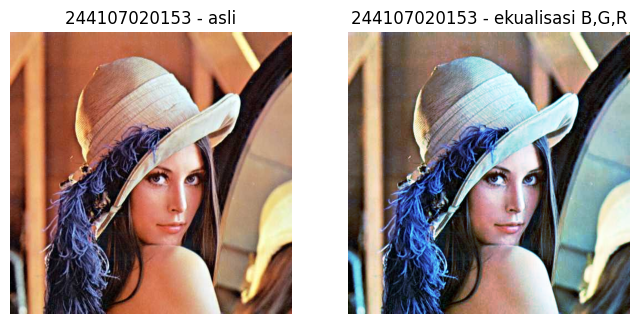

In [10]:
# Step 3 - Ekualisasi kanal B, G, R satu per satu
# Tahap 1: lena.jpg. Tahap 2: KTM1d.jpg
img = CONTOH + '/lena.jpg'          # tahap 1
bgr    = cv.imread(img)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ekualisasi B,G,R')
plt.axis('off')
plt.show()

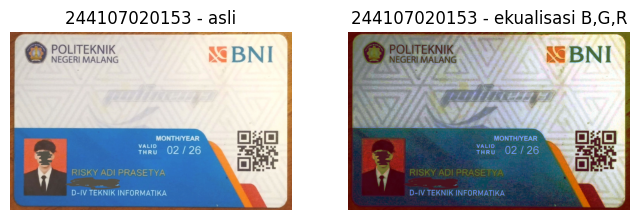

In [11]:
# Step 3 - Ekualisasi kanal B, G, R satu per satu
# Tahap 1: lena.jpg. Tahap 2: KTM1d.jpg
img = BASE + '/KTM1d.jpeg'          # tahap 2: BASE + '/KTM1d.jpg'
bgr    = cv.imread(img)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ekualisasi B,G,R')
plt.axis('off')
plt.show()

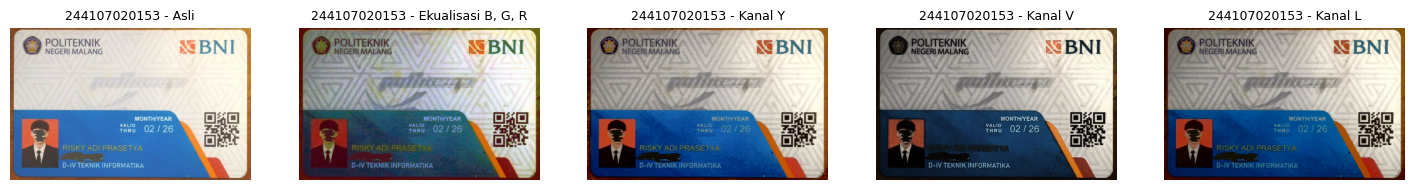

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            173.3
Ekualisasi B, G, R                65.20            129.1
Kanal Y                            1.34            129.4
Kanal V                            2.17            115.1
Kanal L                            3.08            121.8


In [12]:
# Step 4 - Ekualisasi hanya kanal terang (Y / V / L) + pengukuran pergeseran Hue
img = cv.imread(BASE + '/KTM1d.jpeg')

# cara 1 (ulang, agar variabel berbasis KTM1d.jpeg)
kanal = list(cv.split(img))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb     = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y      = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv       = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v      = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab       = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l, a, b   = cv.split(lab)
he_l      = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [img, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(img, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

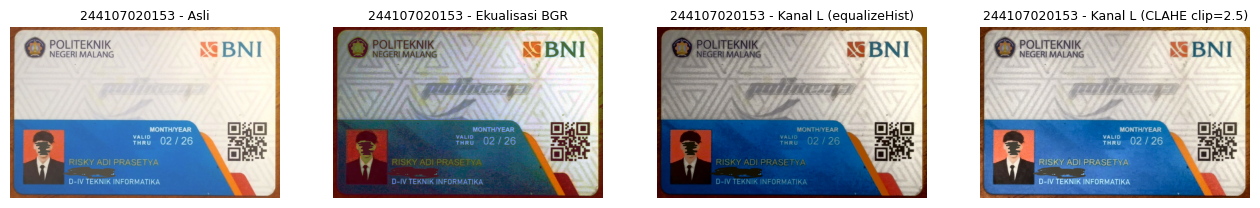

Cara                          geser Hue (der)    rerata terang
Asli                                     0.00            173.3
Ekualisasi BGR                          65.20            129.1
Kanal L (equalizeHist)                   3.08            121.8
Kanal L (CLAHE clip=2.5)                 2.07            157.9


In [18]:
# Soal 4 - Ekualisasi hanya kanal terang (Y / V / L) + pengukuran pergeseran Hue
# Inisialisasi CLAHE sesuai parameter dari PARAM
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

# citra KTM1d
img = cv.imread(BASE + '/KTM1d.jpeg')

# Ekualisasi BGR (Global per kanal secara terpisah)
kanal = list(cv.split(img))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# Ekualisasi Biasa (equalizeHist) pada Kanal L (LAB)
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l_eq = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# Ekualisasi CLAHE pada Kanal L (LAB)
he_l_clahe = cv.cvtColor(cv.merge([clahe.apply(l), a, b]), cv.COLOR_LAB2BGR)

# Perbandingan Visual
judul = [
    'Asli',
    'Ekualisasi BGR',
    'Kanal L (equalizeHist)',
    f"Kanal L (CLAHE clip={PARAM['clip']})"
]
citra = [img, he_rgb, he_l_eq, he_l_clahe]

plt.figure(figsize=(16, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 4, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

# Fungsi Mengukur Pergeseran Hue
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)
    return d.mean()

# Tabel Perbandingan Pergeseran Hue dan Rerata Kecerahan
print('%-28s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-28s %16.2f %16.1f' % (
        t,
        geser_hue(img, c) * 2,
        cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    ))

## PERTANYAAN PRAKTIKUM E2

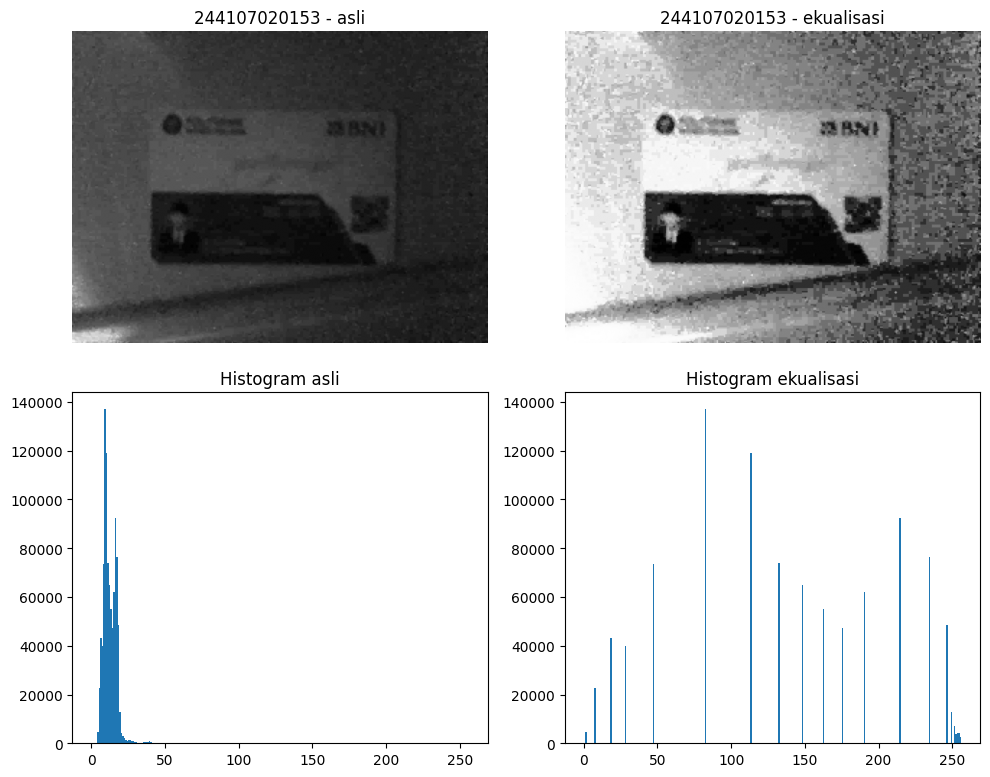

PSNR asli vs ekualisasi: 5.04 dB


In [13]:
# Soal 1 -  Ekualisasi global pada KTM1a.jpg (grayscale)
gray_ktma = cv.imread(BASE + '/KTM1a.jpeg', cv.IMREAD_GRAYSCALE)
eq_manual_gray = hist_eq_manual(gray_ktma)
eq_cv_gray     = cv.equalizeHist(gray_ktma)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(gray_ktma, cmap='gray')
axs[0, 0].set_title(NIM + ' - asli')
axs[0, 0].axis('off')

axs[0, 1].imshow(eq_cv_gray, cmap='gray')
axs[0, 1].set_title(NIM + ' - ekualisasi')
axs[0, 1].axis('off')

axs[1, 0].hist(gray_ktma.ravel(), bins=256, range=(0, 256))
axs[1, 0].set_title('Histogram asli')

axs[1, 1].hist(eq_cv_gray.ravel(), bins=256, range=(0, 256))
axs[1, 1].set_title('Histogram ekualisasi')

plt.tight_layout()
plt.show()

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0**2 / mse)

nilai_psnr = psnr(gray_ktma, eq_cv_gray)
print('PSNR asli vs ekualisasi:', round(nilai_psnr, 2), 'dB')

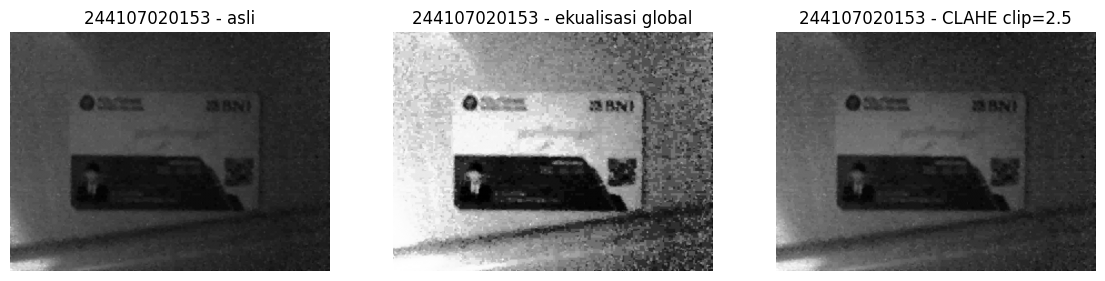

In [14]:
# Soal 2 - CLAHE pada KTM1a.jpeg
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_res = clahe.apply(gray_ktma)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].imshow(gray_ktma, cmap='gray')
axs[0].set_title(NIM + ' - asli')
axs[0].axis('off')

axs[1].imshow(eq_cv_gray, cmap='gray')
axs[1].set_title(NIM + ' - ekualisasi global')
axs[1].axis('off')

axs[2].imshow(clahe_res, cmap='gray')
axs[2].set_title(NIM + f" - CLAHE clip={PARAM['clip']}")
axs[2].axis('off')

plt.show()

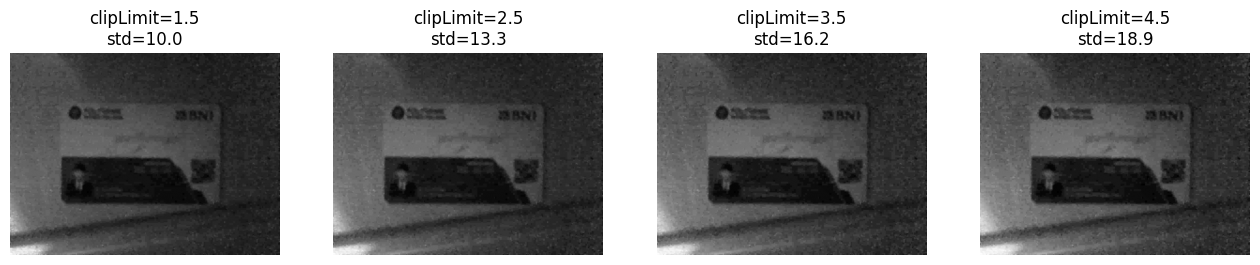

In [15]:
# coba 3 nilai clipLimit lain di sekitar PARAM['clip']
nilai_coba = [max(1.0, PARAM['clip'] - 1.0), PARAM['clip'], PARAM['clip'] + 1.0, PARAM['clip'] + 2.0]
fig, axs = plt.subplots(1, len(nilai_coba), figsize=(4 * len(nilai_coba), 4))

for ax, cl in zip(axs, nilai_coba):
    hasil = cv.createCLAHE(clipLimit=cl, tileGridSize=(PARAM['tile'], PARAM['tile'])).apply(gray_ktma)
    ax.imshow(hasil, cmap='gray')
    ax.set_title(f'clipLimit={cl:.1f}\nstd={hasil.std():.1f}')
    ax.axis('off')

plt.show()